## Importing Libraries

In [9]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

### Loading Model

In [10]:
model  = tf.keras.models.load_model('trained_model.keras')

In [11]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                    

In [14]:
print(model.input_shape)  # Should be (None, 224, 224, 3) if using 224x224 RGB images

(None, 128, 128, 3)


In [24]:
# testing data for metrics
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    'C:/Users/msait/OneDrive/Desktop/for 15epochs/plant_disease_dataset/test/',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("True labels shape:", y_true_onehot.shape)
print("Predicted probabilities shape:", y_pred_prob.shape)

Found 33 images belonging to 1 classes.


True labels shape: (33, 1)
Predicted probabilities shape: (33, 38)


In [16]:
# Check one batch
x, y = next(test_generator)
print(x.shape)  # Should output (32, 128, 128, 3)

(32, 128, 128, 3)


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix

# Predict
y_pred_prob = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred_prob, axis=1)

# True labels
y_true = test_generator.classes

# Metrics
error_rate = 1 - accuracy_score(y_true, y_pred_classes)
print(f"Error Rate: {error_rate:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)


2/2 [==============================] - 0s 13ms/step
Error Rate: 1.0000


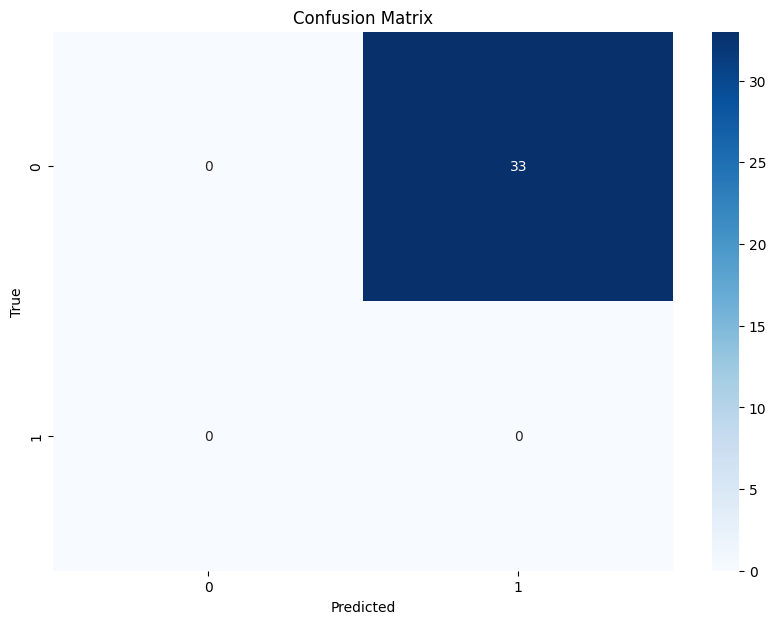

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
# Confusion Matrix Plot
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [32]:
print("Shape of test_generator.classes:", test_generator.classes.shape)
print("Number of classes in generator:", len(test_generator.class_indices))
print("Shape of y_true_onehot:", y_true_onehot.shape)
print("Shape of y_pred_prob:", y_pred_prob.shape)

Shape of test_generator.classes: (33,)
Number of classes in generator: 1
Shape of y_true_onehot: (33, 1)
Shape of y_pred_prob: (33, 38)


### Visualizaing Single Image of Test set

In [4]:
!pip install opencv-python

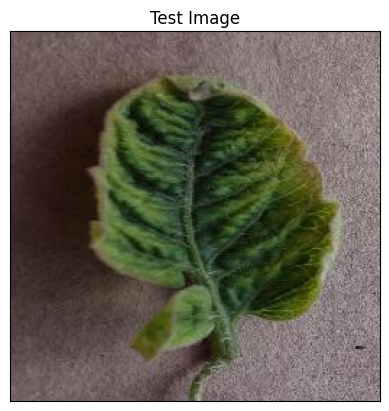

In [5]:
import cv2
image_path = "test/test/TomatoYellowCurlVirus2.JPG"
#Reading Image
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Convert BGR image to RGB

#Displaying Image
plt.imshow(img)
plt.title("Test Image")
plt.xticks([])
plt.yticks([])
plt.show()

## Testing Model

In [6]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128, 128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr]) #Convert single image to a batch
print(input_arr.shape)

(1, 128, 128, 3)


In [7]:
prediction = model.predict(input_arr)
prediction,prediction.shape

1/1 [==============================] - 0s 479ms/step


(array([[5.90704213e-24, 5.26721132e-26, 1.51000650e-21, 1.16702512e-21,
         3.15734345e-22, 5.49502129e-22, 6.54536981e-29, 2.97551076e-23,
         1.59086022e-31, 1.37886702e-23, 7.69858294e-27, 4.86188394e-20,
         1.51339155e-21, 1.27346325e-17, 1.78774177e-27, 2.78534020e-19,
         7.82821623e-24, 4.26301011e-27, 3.02049716e-18, 4.44055610e-23,
         3.85808365e-29, 6.13049918e-19, 2.28412138e-22, 1.26057296e-17,
         1.61727050e-22, 3.47603886e-19, 6.41346539e-20, 1.84584601e-23,
         4.69762487e-17, 8.69996180e-15, 3.43036196e-23, 3.84758021e-19,
         2.43514056e-20, 4.53013900e-17, 1.41083793e-17, 1.00000000e+00,
         4.63809897e-17, 1.00283808e-23]], dtype=float32),
 (1, 38))

In [8]:
result_index = np.argmax(prediction)
result_index

35

In [9]:
class_name = ['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

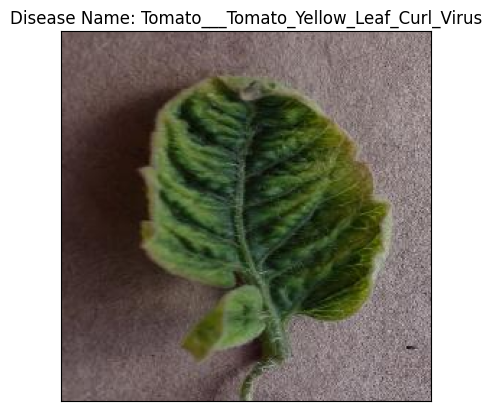

In [10]:
#Displaying Result of disease prediction
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()

In [11]:
model_prediction

'Tomato___Tomato_Yellow_Leaf_Curl_Virus'